# Evaluation Script for Sense Definition Generation

### 1. Run O2C if required
Select `name` of existing run
OR
Fill `paths` and `name` for new run on o2c

In [1]:
import os
import pandas as pd

name="fews_lemur" #s3_lemur_dev2 #s3_generated_definition_dev2
# path and values
BASE_DIR = "/home/users1/saxjs/BASax/johannes/autodict/pipeline"
result_dir = "/home/users1/saxjs/BASax/johannes/eval/results"
dictionary_s3 = "/home/users1/saxjs/BASax/ba_pipeline/OUTFews_short/dev2_gen_def_gen_def_usages.tsv" #"/home/users1/saxjs/BASax/ba_pipeline/OUT2/dev2_gen_def_generated_definition.tsv"
threshold_s3 = 0.4 
model_weights_s3 = os.path.join(BASE_DIR, "outlier2cluster/o2c/data/models/NSD/NSD_own_dev.pkl")
max_usage_length_s3 = 512

#usage_path = os.path.join(BASE_DIR, "data/results/s1/unrecorded.tsv")
usage_path="/home/users1/saxjs/BASax/FEWS/own_dev_fews/GOLD_FEWS_DEF/gold_data_fews.tsv"

#if file exists skip o2c
if os.path.exists(f"{result_dir}/{name}"):
    o2c_req = False  # Set to False if outlier2cluster is NOT required
    print(f"Directory {result_dir}/{name} already exists, skipping outlier2cluster.")
else:
    o2c_req = True
    # create directory if not exists
    os.makedirs(f"{result_dir}/{name}", exist_ok=True)
    print(f"Directory {result_dir}/{name} created, proceeding with outlier2cluster.")

# Run outlier2cluster script from the pipeline
# Only if the directory does not exist
if o2c_req:
    cmd = (
        f'python "{BASE_DIR}/outlier2cluster/o2c/code/main.py" '
        f'--dictionary "{dictionary_s3}" '
        f'--usages "{usage_path}" '
        f'--thresh "{threshold_s3}" '
        f'--result_dir "{result_dir}/{name}" '
        f'--nsd_weights "{model_weights_s3}" '
        f'--context_limit "{max_usage_length_s3}"'
    )
    print("Running:", cmd)
    os.system(cmd)

# load S3 results for specified directory (name)
s3out = pd.read_csv(f"{result_dir}/{name}/result_raw.tsv", sep='\t')
display(s3out.head(2))

Directory /home/users1/saxjs/BASax/johannes/eval/results/fews_lemur already exists, skipping outlier2cluster.


,identifier,sense_id,prob,context,lemma,label,indexes_target_token,indexes_target_sentence,pos,date,grouping,description
0,0,pleasantly.adverb.0,0.378486,"In workhouses, pleasantly so named, because wo...",pleasantly,0,15:25,0:72,NaN,NaN,NaN,NaN
1,1,remembrance.noun.0,0.042679,Thee I have heard relating what was done / Ere...,remembrance,0,50:61,0:132,NaN,NaN,NaN,NaN


### 2. load gold data
Load binary labeled data using the `label` column

In [2]:

# load gold
gold_data = pd.read_csv("/home/users1/saxjs/BASax/FEWS/own_dev_fews/GOLD_FEWS_DEF/gold_data_fews.tsv", sep='\t')

### 3. create PR curve

Test labels: [1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1,

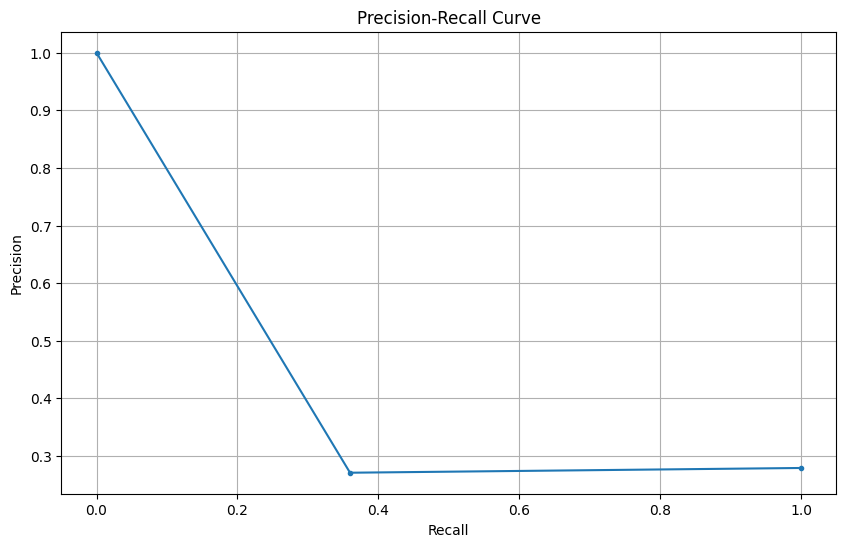

In [3]:
# List for storing labels
# 0: No assigned Fews sense (negative label)
# 1: Assigned Fews sense (positive label)
gold_label= []
test_label = []

# Extract gold labels from the gold data
gold_label = gold_data['label'].tolist()

# map model predictions to binary values
for row in s3out.itertuples():
    # Check if sense_id of fews got assigned
    if '0.0' in str(row.sense_id) or '1.0' in str(row.sense_id) or '2.0' in str(row.sense_id):
        test_label.append(0)  # No assigned Fews sense is negative label
    else:
        test_label.append(1)  

print("Test labels:", test_label)
print("Gold labels:", gold_label)

# Plot Precision-Recall Curve
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
precision, recall, thresholds = precision_recall_curve(gold_label, test_label, pos_label=1)
plt.figure(figsize=(10, 6))
plt.plot(recall, precision, marker='.')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid()
plt.show()


In [4]:
from sklearn.metrics import f1_score
print("Calculating F1 Score(positive class unrecorded (0))...")
f1 = f1_score(gold_label, test_label,average='binary', pos_label=0,zero_division=0)
print("F1 Score:", f1)
print("Calculating F1 Score(positive class unrecorded (1))...")
f1 = f1_score(gold_label, test_label,average='binary', pos_label=1,zero_division=0)
print("F1 Score:", f1)

print("Calculating Accuracy...")
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(gold_label, test_label)
print("Accuracy:", accuracy)

Calculating F1 Score(positive class unrecorded (0))...
F1 Score: 0.6674566730854689
Calculating F1 Score(positive class unrecorded (1))...
F1 Score: 0.3090181594336719
Calculating Accuracy...
Accuracy: 0.551


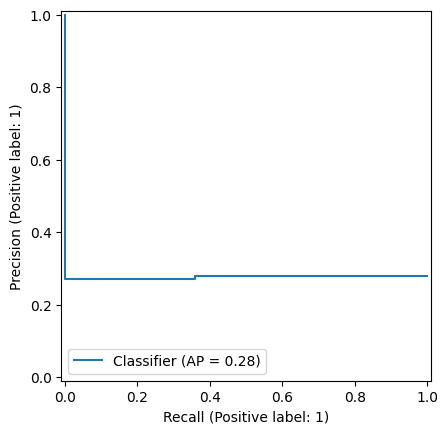

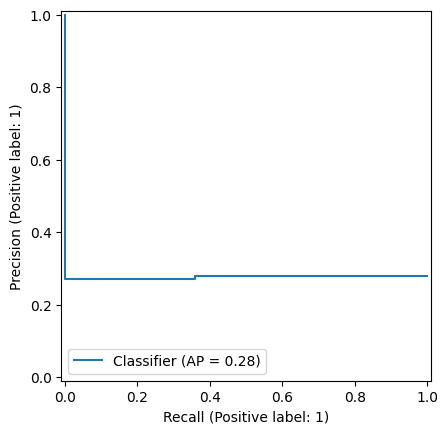

In [5]:
from sklearn.metrics import PrecisionRecallDisplay
display = PrecisionRecallDisplay.from_predictions(gold_label, test_label)
display.plot()